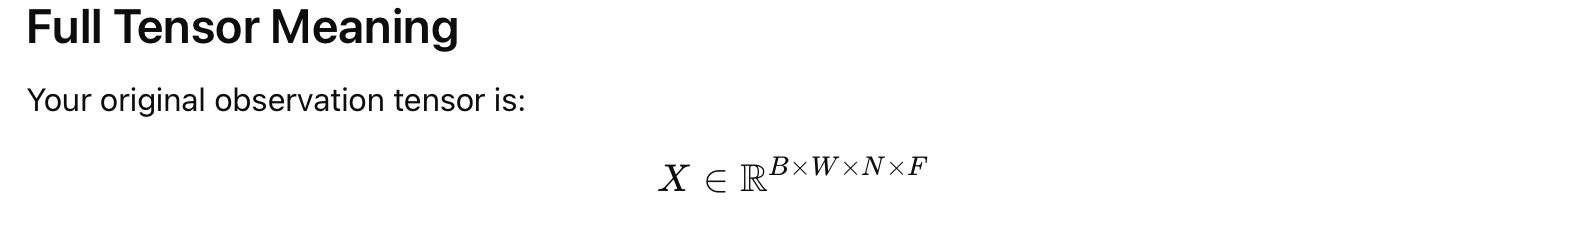

(Batch,
 Historical Time Window,
 Assets,
 Features)

 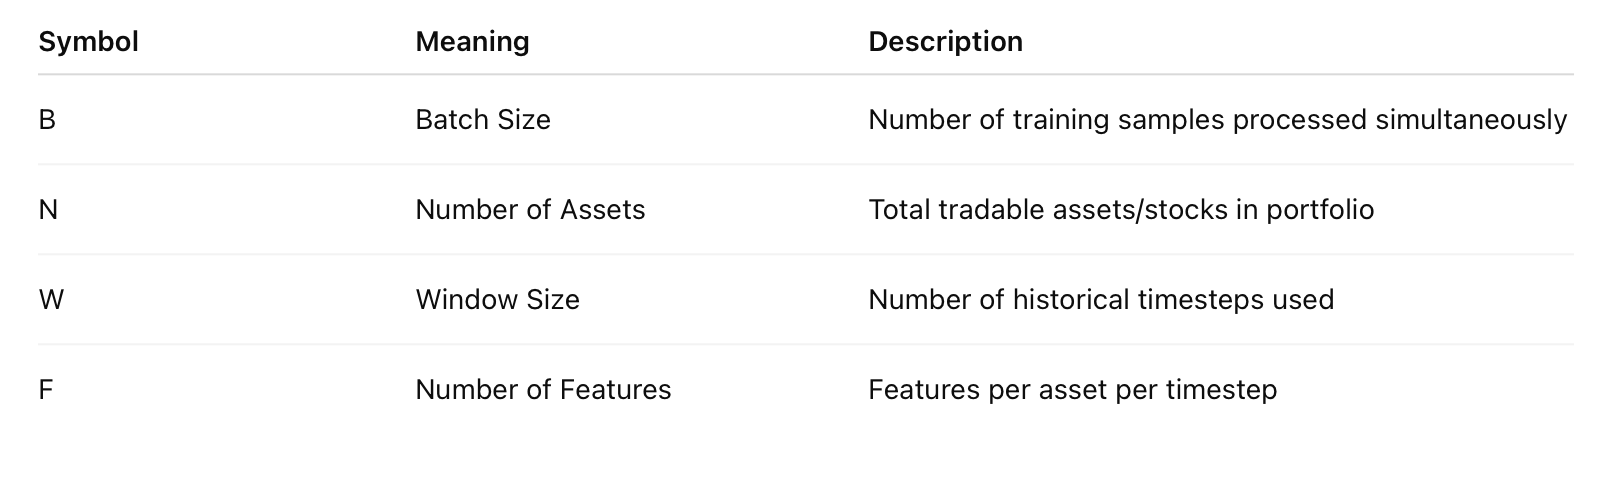

In [1]:
import sys
!{sys.executable} -m pip install graphviz


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3.14 install --upgrade pip


In [2]:
from graphviz import Digraph

dot = Digraph(
    "HybridRLArchitecture",
    format="png"
)

# dot.attr(rankdir="LR")
dot.attr(rankdir="TD")
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fillcolor="lightblue",
    fontsize="12"
)

# Input
dot.node(
    "Input",
    "Input Tensor\n(B, Window, Assets, Features)\n\nFeatures:\nReturns\nVolatility\nZ-Score\nSentiment"
)

# Temporal
dot.node(
    "Permute",
    "Permute & Reshape\n(B,N,W,F)"
)

dot.node(
    "LSTM",
    "LSTM Temporal Encoder\nInput Size = 4\nHidden Size = 32"
)

dot.node(
    "TemporalEmbedding",
    "Temporal Embeddings\n(B,N,32)"
)

# Graph
dot.node(
    "Adjacency",
    "Adjacency Matrix\nCorrelation Graph\n(9x9)"
)

dot.node(
    "GraphAgg",
    "Graph Aggregation\nA × X"
)

dot.node(
    "GCNMLP",
    "GCN Asset MLP\nLinear(32→32)\nReLU\nLinear(32→32)"
)

# Portfolio
dot.node(
    "Flatten",
    "Flatten Asset Embeddings"
)

dot.node(
    "Weights",
    "Portfolio Weights\n(B,N)"
)

dot.node(
    "Concat",
    "Concatenate\nEmbeddings + Weights"
)

# Final
dot.node(
    "FinalMLP",
    "Final Dense Layers\nLinear → ReLU → Linear"
)

dot.node(
    "Output",
    "Feature Vector\n(features_dim=256)"
)

dot.node(
    "PPO",
    "PPO Policy Network\nAction Allocation"
)

# Connections
dot.edge("Input", "Permute")
dot.edge("Permute", "LSTM")
dot.edge("LSTM", "TemporalEmbedding")

dot.edge("TemporalEmbedding", "GraphAgg")
dot.edge("Adjacency", "GraphAgg")

dot.edge("GraphAgg", "GCNMLP")
dot.edge("GCNMLP", "Flatten")

dot.edge("Flatten", "Concat")
dot.edge("Weights", "Concat")

dot.edge("Concat", "FinalMLP")
dot.edge("FinalMLP", "Output")
dot.edge("Output", "PPO")

dot.render("hybrid_rl_architecture", cleanup=True)

print("Architecture diagram generated.")

Architecture diagram generated.


In [3]:
from graphviz import Digraph

dot = Digraph(
    "GCNExtractorArchitecture",
    format="png"
)

#dot.attr(rankdir="LR")
dot.attr(rankdir="TD")

dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fillcolor="lightgreen",
    fontsize="12"
)

# Input
dot.node(
    "Input",
    "Input Features\n(B,N,F)\n\nFeatures:\nReturns\nVolatility\nZ-Score\nSentiment"
)

# Graph
dot.node(
    "Adjacency",
    "Adjacency Matrix\nCorrelation Graph\n(9x9)"
)

dot.node(
    "GraphAgg",
    "Graph Aggregation\nA × X"
)

dot.node(
    "GCN1",
    "GCN Layer 1\nLinear(F→32)\nReLU"
)

dot.node(
    "GCN2",
    "GCN Layer 2\nLinear(32→32)\nReLU"
)

dot.node(
    "Flatten",
    "Flatten Graph Embeddings"
)

dot.node(
    "Weights",
    "Portfolio Weights\n(B,N)"
)

dot.node(
    "Concat",
    "Concatenate\nEmbeddings + Weights"
)

dot.node(
    "FinalMLP",
    "Final Dense Layers"
)

dot.node(
    "Output",
    "Feature Vector\n(features_dim=256)"
)

dot.node(
    "PPO",
    "PPO Policy Network"
)

# Connections
dot.edge("Input", "GraphAgg")
dot.edge("Adjacency", "GraphAgg")

dot.edge("GraphAgg", "GCN1")
dot.edge("GCN1", "GCN2")

dot.edge("GCN2", "Flatten")

dot.edge("Flatten", "Concat")
dot.edge("Weights", "Concat")

dot.edge("Concat", "FinalMLP")

dot.edge("FinalMLP", "Output")

dot.edge("Output", "PPO")

dot.render("gcn_extractor_architecture", cleanup=True)

print("GCN extractor architecture generated.")

GCN extractor architecture generated.


In [4]:
import sys
!{sys.executable} -m pip install diagrams


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip3.14 install --upgrade pip


In [6]:
from diagrams import Diagram, Cluster
from diagrams.generic.compute import Rack

with Diagram(
    "GCN Extractor Architecture",
    show=False,
    direction="TD",
    filename="gcn_architecture"
):

    input_data = Rack("Input Features\n(B,N,F)")

    adjacency = Rack("Adjacency Matrix")

    graph_agg = Rack("Graph Aggregation\nA×X")

    with Cluster("GCN Layers"):

        gcn1 = Rack("GCN Layer 1")

        gcn2 = Rack("GCN Layer 2")

    flatten = Rack("Flatten Embeddings")

    weights = Rack("Portfolio Weights")

    concat = Rack("Concatenate")

    final = Rack("Final Dense Layers")

    ppo = Rack("PPO Policy")

    input_data >> graph_agg
    adjacency >> graph_agg

    graph_agg >> gcn1 >> gcn2

    gcn2 >> flatten

    flatten >> concat
    weights >> concat

    concat >> final >> ppo

ValueError: "TD" is not a valid direction

In [7]:
from graphviz import Digraph

dot = Digraph(
    "DefaultPPOExtractor",
    format="png"
)

#dot.attr(rankdir="LR")
dot.attr(rankdir="TD")
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fillcolor="lightyellow",
    fontsize="12"
)

dot.node(
    "Input",
    "Flattened Observation\n(B, Features)"
)

dot.node(
    "MLP1",
    "Dense Layer\nLinear → ReLU"
)

dot.node(
    "MLP2",
    "Dense Layer\nLinear → ReLU"
)

dot.node(
    "FeatureVector",
    "Feature Embedding"
)

dot.node(
    "Actor",
    "Actor Network\nPortfolio Weights"
)

dot.node(
    "Critic",
    "Critic Network\nValue Function"
)

dot.edge("Input", "MLP1")

dot.edge("MLP1", "MLP2")

dot.edge("MLP2", "FeatureVector")

dot.edge("FeatureVector", "Actor")

dot.edge("FeatureVector", "Critic")

dot.render(
    "default_ppo_extractor",
    cleanup=True
)

print("Default PPO extractor diagram generated.")

Default PPO extractor diagram generated.


In [8]:
from diagrams import Diagram
from diagrams.programming.framework import Pytorch
from diagrams.generic.compute import Rack

with Diagram(
    "Default PPO Feature Extractor",
    show=False,
    direction="TD",
    filename="default_ppo_extractor"
):

    input_layer = Rack(
        "Flattened Observation"
    )

    mlp1 = Pytorch(
        "Dense Layer 1"
    )

    mlp2 = Pytorch(
        "Dense Layer 2"
    )

    features = Rack(
        "Feature Embedding"
    )

    actor = Pytorch(
        "Actor Network"
    )

    critic = Pytorch(
        "Critic Network"
    )

    input_layer >> mlp1 >> mlp2 >> features

    features >> actor
    features >> critic

ImportError: cannot import name 'Pytorch' from 'diagrams.programming.framework' (/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/diagrams/programming/framework.py)

In [11]:
from graphviz import Digraph

dot = Digraph(
    "CompleteRLTraderArchitecture",
    format="png"
)

#dot.attr(rankdir="LR")
dot.attr(rankdir="TD")
dot.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fillcolor="lightcyan",
    fontsize="11"
)

# Data Pipeline
dot.node(
    "DataPipeline",
    "Data Pipeline\n\nYahoo Finance\nReturns\nVolatility\nZ-Score\nSentiment"
)

dot.node(
    "FeatureTensor",
    "Feature Tensor\n(B,W,N,F)"
)

# Environment
dot.node(
    "Environment",
    "MultiAssetTradingEnv\n\nPortfolio Simulation\nReward Function\nTransaction Cost\nDrawdown"
)

# Hybrid Flow
dot.node(
    "Hybrid",
    "Hybrid Extractor\nLSTM + GCN"
)

# GCN Flow
dot.node(
    "GCN",
    "Pure GCN Extractor"
)

# Default Flow
dot.node(
    "Default",
    "Default PPO Extractor\nMLP"
)

# PPO
dot.node(
    "PPO",
    "PPO Agent\nActor-Critic"
)

# Backtester
dot.node(
    "Backtester",
    "Backtester\n\nPortfolio Metrics\nXIRR\nVolatility\nDrawdown"
)

# Outputs
dot.node(
    "Output",
    "Portfolio Allocation\nTrading Decisions"
)

# Flow
dot.edge("DataPipeline", "FeatureTensor")

dot.edge("FeatureTensor", "Environment")

dot.edge("Environment", "Hybrid")

dot.edge("Environment", "GCN")

dot.edge("Environment", "Default")

dot.edge("Hybrid", "PPO")

dot.edge("GCN", "PPO")

dot.edge("Default", "PPO")

dot.edge("PPO", "Output")

dot.edge("Output", "Backtester")

dot.render(
    "complete_rl_trader_architecture",
    cleanup=True
)

print("Complete RL trader architecture generated.")

Complete RL trader architecture generated.


# Reinforcement Learning Portfolio Optimization using Multiple Feature Extractors

## Overview

This research investigates three different feature extraction architectures for Reinforcement Learning based portfolio optimization using PPO (Proximal Policy Optimization).

The architectures compared are:

1. Default PPO Feature Extractor
2. Pure GCN Feature Extractor
3. Hybrid Temporal + Graph Feature Extractor

---

# 1. Default PPO Feature Extractor

## Architecture

The default PPO feature extractor uses fully connected dense neural networks (MLP) to transform flattened observations into latent feature embeddings.

### Characteristics

- No temporal modeling
- No graph modeling
- Simple feed-forward neural network
- Fast training
- Low computational cost

## Benefits

- Simple architecture
- Easy convergence
- Stable PPO training
- Lower memory usage
- Faster experimentation

## Challenges

- Cannot model temporal dependencies
- Cannot learn asset relationships
- Limited understanding of market dynamics
- Weak portfolio diversification intelligence

## Expected Outcome

- Stable baseline performance
- Lower computational complexity
- Lower Sharpe ratio compared to graph-based methods
- Reduced capability in volatile market regimes

---

# 2. Pure GCN Feature Extractor

## Architecture

The GCN extractor models relationships between assets using a graph adjacency matrix generated from correlation structures.

### Characteristics

- Learns inter-asset relationships
- Graph aggregation using adjacency matrix
- Captures sector-wise behavior
- Portfolio-aware relational learning

## Benefits

- Models asset correlations
- Better diversification learning
- Improved portfolio balancing
- Stronger market structure understanding

## Challenges

- No temporal sequence learning
- Cannot model momentum or trend persistence
- Sensitive to adjacency matrix quality
- Graph instability in rapidly changing markets

## Expected Outcome

- Better diversification
- Improved drawdown control
- Stronger risk-adjusted return
- Better sector rotation learning

---

# 3. Hybrid Temporal + Graph Feature Extractor

## Architecture

The hybrid extractor combines:

- LSTM temporal encoder
- Graph neural network
- PPO reinforcement learning

### Characteristics

- Temporal sequence learning
- Graph-based relational learning
- Asset dependency modeling
- Historical market regime learning

## Benefits

- Learns trends and momentum
- Learns inter-asset relationships
- Improved regime adaptation
- Strong portfolio intelligence
- Better volatility handling

## Challenges

- Higher computational cost
- More difficult hyperparameter tuning
- Increased training complexity
- Larger memory requirements

## Expected Outcome

- Highest Sharpe ratio
- Better long-term portfolio growth
- Superior drawdown management
- Improved market regime adaptation
- Better transaction efficiency

---

# Comparative Summary

| Extractor | Temporal Learning | Graph Learning | Complexity | Expected Performance |
|---|---|---|---|---|
| Default PPO | No | No | Low | Baseline |
| Pure GCN | No | Yes | Medium | Better Diversification |
| Hybrid LSTM+GCN | Yes | Yes | High | Best Overall |

---

# Conclusion

The hybrid temporal-graph architecture is expected to outperform the baseline PPO and pure GCN architectures due to its ability to jointly learn:

- Historical market behavior
- Asset relationships
- Portfolio allocation dynamics

This architecture is particularly suitable for:

- Multi-asset portfolio optimization
- Volatility-aware trading
- Risk-sensitive reinforcement learning
- Long-horizon financial decision making